# 00 — Deep-notched forward isotropic

This notebook runs one `deep_notched` training with default config values, forcing only:

1. `task.type = "forward"`
2. `problem.material.law = "isotropic"`

Then it plots the final predicted fields.

In [1]:
from pathlib import Path
import importlib

import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.deep_notched as dn
from phd.plot import book_config, get_current_config as plt_cfg

# Ensure notebook uses latest local edits in deep_notched.py
dn = importlib.reload(dn)

book_config.set_as_current()
plot_cfg = plt_cfg()
page_width = plot_cfg.page_width if plot_cfg is not None else 7.0

save_fig = False
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "02_deep_notched"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [2]:
def build_forward_isotropic_cfg(seed: int = 0):
    cfg = load_config("deep_notched")

    cfg.seed = seed
    cfg.task.type = "forward"
    cfg.problem.material.law = "isotropic"

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 5
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.mlp_type = "modified_mlp"
    cfg.model.fourier_features.enabled = True
    cfg.model.fourier_features.n_features = 64

    cfg.training.n_iter = 30000
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 1e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 150 ** 2
    cfg.training.coord_normalization = True
    cfg.training.self_attention.enabled = True
    # cfg.training.loss_weights = [1.0]*5 + [1e2]*2
    cfg.training.loss_normalization.scheme = "grad_norm"

    # cfg.bc.displacement_bc = True

    return cfg

In [3]:
# 1) Run one forward isotropic case
cfg = build_forward_isotropic_cfg(seed=0)
results = dn.train(cfg)

Set the default automatic differentiation to forward mode.


W0219 16:03:46.625777 3618268 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0219 16:03:46.628605 3618141 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


Compiling model...
'compile' took 2.991180 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
0         [3.75e-02, 4.90e-02, 2.00e+04, 3.70e+03, 2.64e+03, 3.14e+03, 3.61e+00, 3.00e+00]    [3.77e-02, 4.91e-02, 2.00e+04, 3.71e+03, 2.64e+03, 3.14e+03, 3.61e+00, 3.00e+00]    [1.01e+00]    
100       [2.30e-02, 3.27e-02, 1.79e+02, 1.11e+02, 1.34e+02, 2.09e+01, 7.52e-01, 7.65e-01]    [2.28e-02, 3.23e-02, 1.74e+02, 1.09e+02, 1.30e+02, 2.09e+01, 7.52e-01, 7.65e-01]    [1.01e+00]    

Best model at step 100:
  train loss: 4.47e+02
  test loss: 4.36e+02
  test metric: [1.01e+00]

'train' took 31.487614 s

Applying loss weighting scheme: grad_norm
  base_loss_weights=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  grad_norms=[0.16005894541740417, 0.26931285858154297, 2540.248291015625, 1450.4512939453125, 1568.0782470703125, 928.41021728515

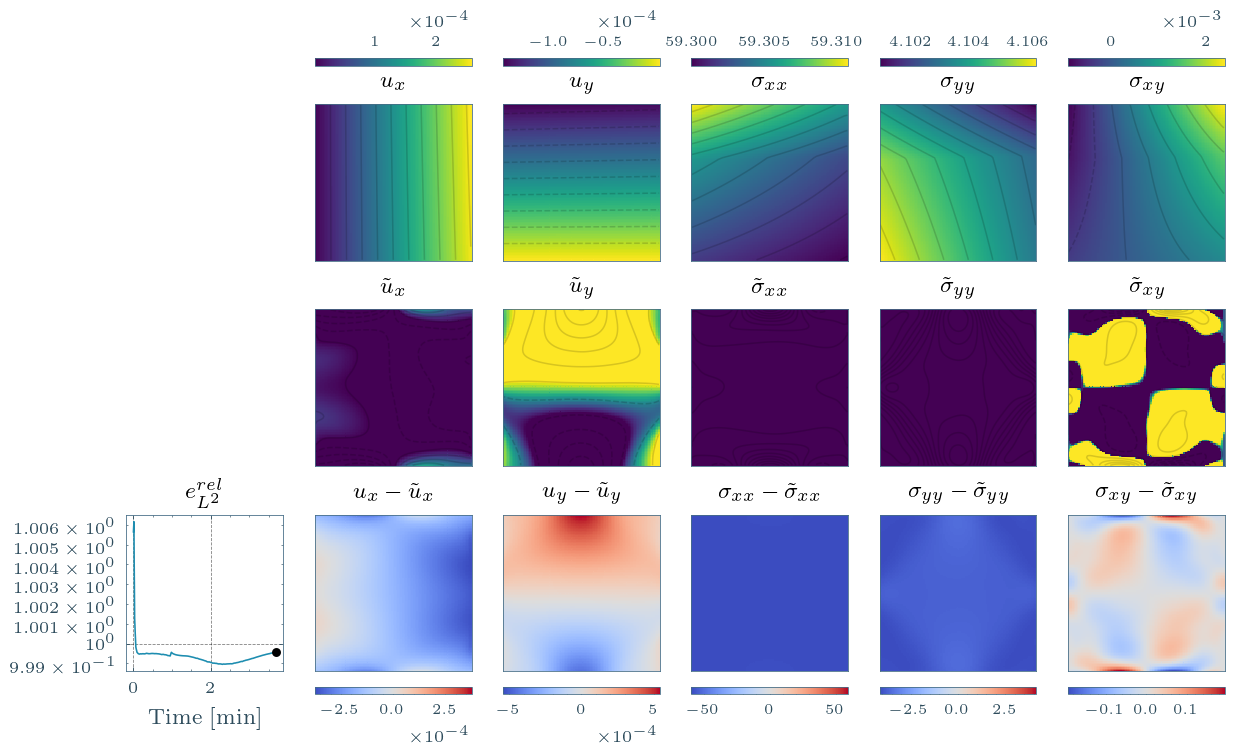

In [4]:
# 2) Plot final prediction
fig, artists = dn.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
)
plt.show()

# if save_fig:
#     fig_name = "forward_isotropic"
#     fig.savefig(IMAGE_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
#     fig.savefig(PDF_DIR / f"{fig_name}.pdf", bbox_inches="tight")
#     print(f"Saved: {IMAGE_DIR / (fig_name + '.png')}")
#     print(f"Saved: {PDF_DIR / (fig_name + '.pdf')}")